# Job Function Exploration

# Setup

## Packages

In [1]:
# General packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

## Import Data

In [2]:
# import data
aff = pd.read_csv("../data/raw/job_affiliations.csv")

aff = aff.replace(r"^\s*$", pd.NA, regex=True)

In [3]:
aff.sample(200, random_state = 34).to_csv('../data/raw_data_sample.csv')

# EDA

In [4]:
aff.info()

<class 'pandas.DataFrame'>
RangeIndex: 109485 entries, 0 to 109484
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   affiliate_id_18   109485 non-null  str  
 1   function          90572 non-null   str  
 2   title             51280 non-null   str  
 3   role              46778 non-null   str  
 4   management_level  70720 non-null   str  
 5   role_level        29230 non-null   str  
dtypes: str(6)
memory usage: 5.0 MB


In [5]:
aff.head()

,affiliate_id_18,function,title,role,management_level,role_level
0,a0d3300000CSzeXAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN
1,a0d3300000CSzjSAAT,General Management,NaN,Special Associate to the President,NaN,NaN
2,a0d3300000CSzjUAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN
3,a0d3300000CSzo6AAD,Academics (Teaching & Learning),NaN,Talented and Gifted Teacher,NaN,NaN
4,a0d3300000CSzo7AAD,Academics (Teaching & Learning),NaN,Elementary Teacher,NaN,NaN


## Check Duplicates

## Missing Values

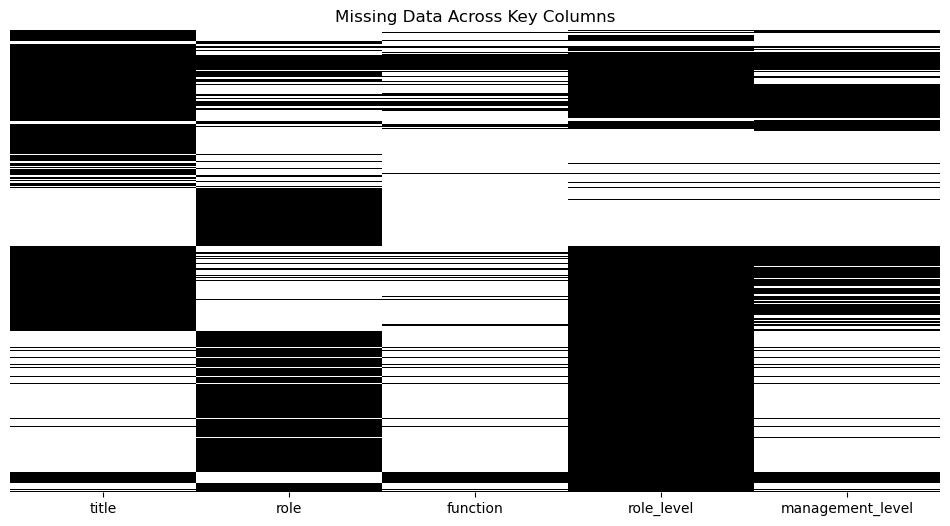

In [6]:
# missing value heatmap
needed_columns = ['title', 'role', 'function', 'role_level', 'management_level']

plt.figure(figsize=(12, 6))

sns.heatmap(
    aff[needed_columns].isnull(),
    cmap=ListedColormap(['white', 'black']),
    cbar=False,
    yticklabels=False
)

plt.title('Missing Data Across Key Columns')
plt.show()

In [7]:
# missing values in role and title
missing_role_perc = round(aff['role'].isna().mean()*100,0).astype(int)
missing_title_perc = round(aff['title'].isna().mean()*100,0).astype(int)
missing_role_level_perc = round(aff['role_level'].isna().mean()*100,0).astype(int)
missing_management_level_perc = round(aff['management_level'].isna().mean()*100,0).astype(int)

print(f"{missing_role_perc}% records missing role")
print(f"{missing_title_perc}% records missing title")
print(f"{missing_role_level_perc}% records missing role level")
print(f"{missing_management_level_perc}% records missing management level")

57% records missing role
53% records missing title
73% records missing role level
35% records missing management level


In [8]:
role_nan_mask = aff['role'].isna()
title_nan_mask = aff['title'].isna()

role_title_nan_pct = int(round(len(aff[role_nan_mask & title_nan_mask])*100/len(aff),0))
print(f'{role_title_nan_pct}% of records missing both title and role')

11% of records missing both title and role


In [9]:
# how many that have a role do and don't have a title?

## Categorical Columns: function, management_level, and role_level

### Job Functions

In [10]:
function_counts = aff["function"].value_counts().reset_index()
display(function_counts)

,function,count
0,Academics (Teaching & Learning),23084
1,Data / Analytics / Research,10418
2,Program and Project Management,8817
3,General Management,8566
4,Operations,5585
5,Academics (Teaching and Learning),4321
6,Consulting,3925
7,Marketing / Communications / External Relations,3671
8,School Leadership / Administration,3314
9,Finance / Budgeting / Accounting,2993


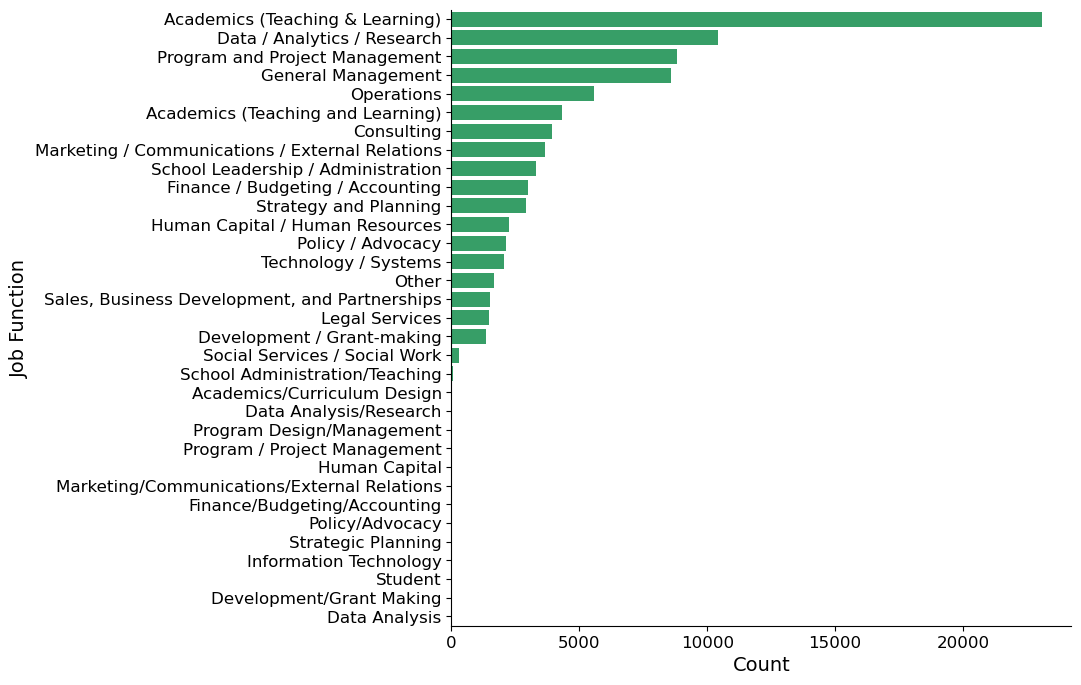

In [11]:
# visualization
function_class_dist = aff['function'].value_counts().index
plt.figure(figsize=(8, 8)) 
sns.countplot(data=aff, y='function', order=function_class_dist, color = '#26AF66')
plt.xlabel("Count", fontsize = 14)
plt.ylabel("Job Function", fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


plt.savefig(
    "../outputs/visualizations/cleaned/job_functions_raw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

### Management Level

In [12]:
management_level_counts = aff["management_level"].value_counts().reset_index()
display(management_level_counts)

,management_level,count
0,Manages self/projects - 1,32482
1,Manages others - 2,15345
2,Manages self/projects,6097
3,Manages a group - 5,3758
4,Manages function(s) - 4,3549
5,Manages others,2586
6,Manages managers - 3,2275
7,Manages organization - 6,1919
8,Manages a group,1221
9,Manages function(s),835


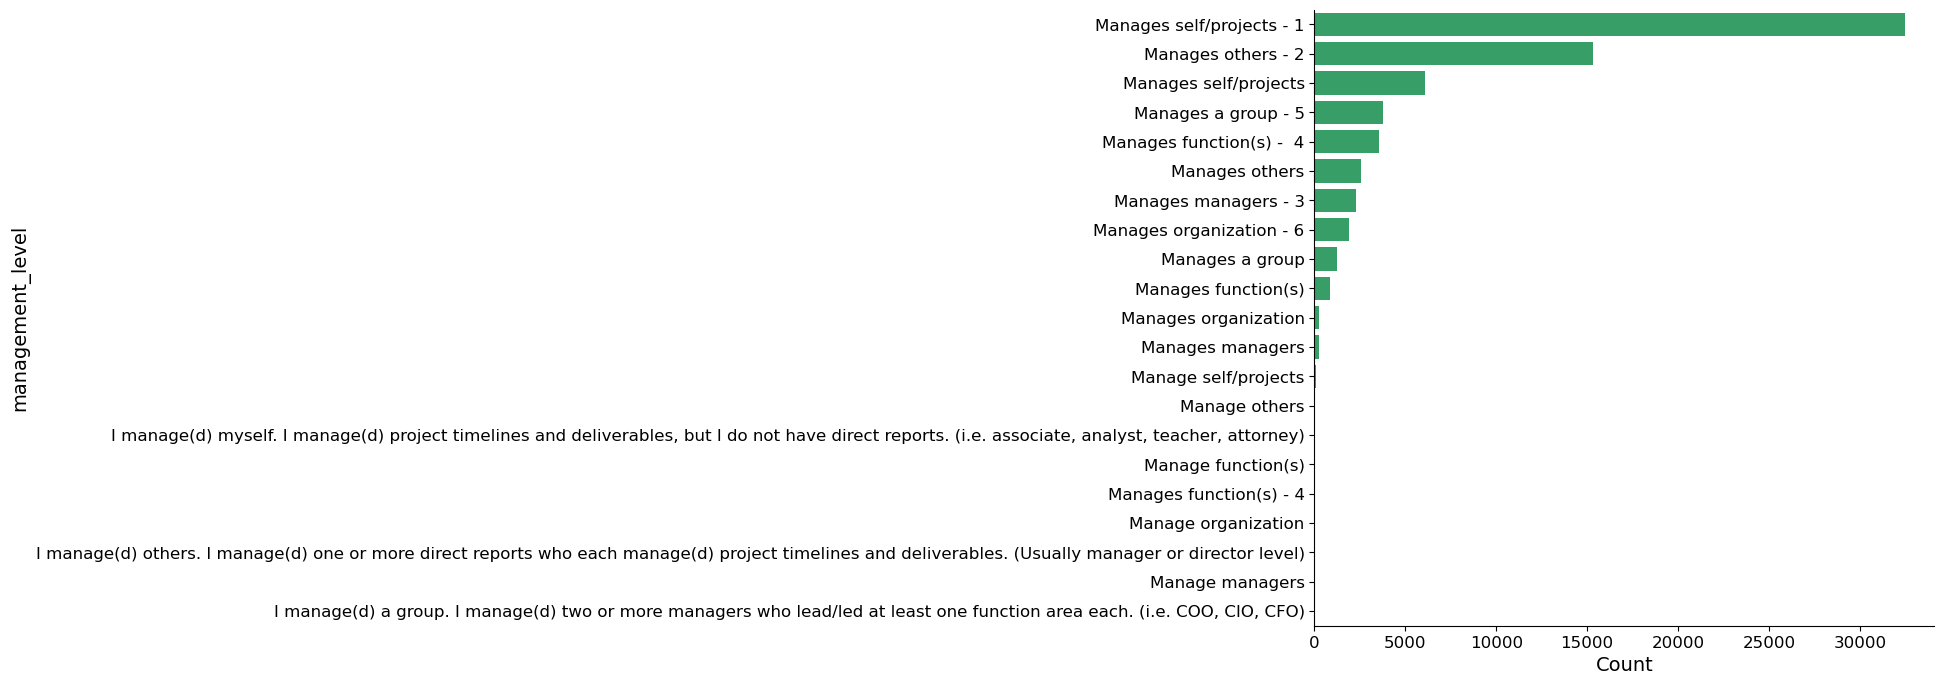

In [ ]:
# visualization
management_class_dist = aff['management_level'].value_counts().index
plt.figure(figsize=(8, 8)) 
sns.countplot(data=aff, y='management_level', order=management_class_dist, color = '#26AF66')
plt.xlabel("Count", fontsize = 14)
plt.ylabel("Management Level", fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "../outputs/visualizations/cleaned/management_levels_raw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

### Role Level

In [14]:
role_level_counts = aff["role_level"].value_counts().reset_index()
display(role_level_counts)

,role_level,count
0,Junior-level (0-3 years),6474
1,Mid-level (5-7 years),3775
2,Junior-level,3315
3,Junior to Mid-level (3-5 years),3303
4,Junior to Mid-level,3063
5,Mid-level,3029
6,Mid to Senior-level (7-10 years),2215
7,Senior-level (10+ years),1590
8,Mid to Senior-level,1452
9,Senior-level,1008


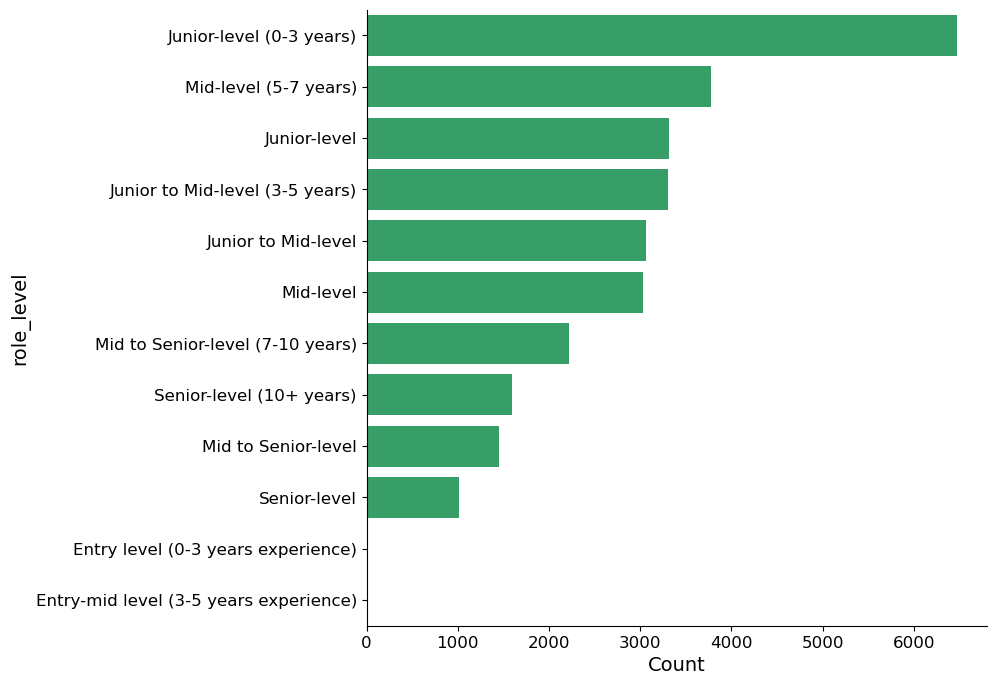

In [ ]:
# visualization
role_class_dist = aff['role_level'].value_counts().index
plt.figure(figsize=(8, 8)) 
sns.countplot(data=aff, y='role_level', order=role_class_dist, color = '#26AF66')
plt.xlabel("Count", fontsize = 14)
plt.ylabel("Role Level", fontsize = 14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig(
    "../outputs/visualizations/cleaned/role_levels_raw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## Free Response Columns: Role and Title

In [16]:
# comparing role and title
has_role_mask = (aff['role'].notna()) & (aff['role'] != '')
has_title_mask = (aff['title'].notna()) & (aff['title'] != '')

role_title_df = aff[has_role_mask & has_title_mask]
role_title_len = len(role_title_df)

role_title_match = role_title_df[role_title_df['role'] == role_title_df['title']]
role_title_match_len = len(role_title_match)

display(role_title_match)

print(f"For records with both role and title, {round((role_title_match_len*100)/role_title_len, 0)}% of job roles match job titles")


,affiliate_id_18,function,title,role,management_level,role_level
239,a0d3300000CT68MAAT,Academics (Teaching & Learning),7th Grade Social Studies,7th Grade Social Studies,Manages self/projects - 1,Senior-level (10+ years)
243,a0d3300000CT6NCAA1,Academics (Teaching & Learning),Teacher in Residence,Teacher in Residence,NaN,Junior-level (0-3 years)
244,a0d3300000CT6NRAA1,Policy / Advocacy,Program and Volunteer Manager,Program and Volunteer Manager,NaN,Junior to Mid-level (3-5 years)
252,a0d3300000CT6RTAA1,Academics (Teaching & Learning),Certified Teacher,Certified Teacher,NaN,Junior to Mid-level (3-5 years)
263,a0d3300000CT6rSAAT,Academics (Teaching & Learning),Grade Level Chair / Department Chair / Teacher...,Grade Level Chair / Department Chair / Teacher...,NaN,Senior-level (10+ years)
...,...,...,...,...,...,...
109479,a0df300000HgKHOAA3,General Management,Executive Director,Executive Director,Manages organization - 6,Senior-level (10+ years)
109480,a0df300000HgKHSAA3,Human Capital / Human Resources,Director of Talent,Director of Talent,NaN,Junior to Mid-level (3-5 years)
109481,a0df300000HgKHXAA3,General Management,Project Director,Project Director,Manages self/projects - 1,Mid to Senior-level (7-10 years)
109482,a0df300000HgKHhAAN,Program and Project Management,Director of Research and Senior Program Office...,Director of Research and Senior Program Office...,NaN,NaN


For records with both role and title, 81.0% of job roles match job titles
